# Purpose\n\nThis notebook selects the final feature set that will be used for volatility prediction modeling.\n\n`01_feature_engineering.ipynb` built a wide set of candidate features (lagged returns, rolling returns, return magnitude, rolling volatility, moving averages) plus macro columns from FRED. Not all of these are equally useful, and several are close variations of each other (for example `squared_return` and `rolling_squared_return_20d` measure similar things at different time scales).\n\nThe goal here is to:\n\n- Check how each candidate feature correlates with the target, `future_volatility_20d`.\n- Check which candidate features are highly correlated with each other (redundant/multicollinear).\n- Rank features using two model-based methods: Random Forest importance and mutual information.\n- Combine everything into one ranking and pick a final feature list for the modeling notebooks.\n\nAll of this is done using only the training portion of the data (dates before 2024-01-01), the same split used in `notebooks/04_modeling/`, so the feature selection decisions are not influenced by the test period."

# Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression

# ENUM Paths

In [2]:
FEATURE_DATA_PATH = Path('../../data/processed/features')
FEATURE_DATA_PATH.mkdir(parents=True, exist_ok=True)

# Import Feature-Engineered Dataset

In [3]:
df = pd.read_csv(
    FEATURE_DATA_PATH / 'feature_engineered_dataset.csv',
    parse_dates=['Date']
)

df.shape

(41370, 30)

# Define Candidate Features and Target

This is the full candidate pool from feature engineering (numeric features only — `ticker`, `company_name`, `gics_sector`, and `asset_type` are identifiers/categoricals, not numeric model inputs). `future_volatility_20d` is the target and is excluded from the candidate list.

In [4]:
TARGET_COL = "future_volatility_20d"

CANDIDATE_FEATURES = [
    "return_lag_1",
    "return_lag_5",
    "rolling_return_5d",
    "rolling_return_20d",
    "abs_return",
    "squared_return",
    "rolling_abs_return_20d",
    "rolling_squared_return_20d",
    "rolling_volatility_5d",
    "rolling_volatility_20d",
    "moving_avg_20d",
    "price_to_moving_avg_20d",
    "risk_free_rate_decimal",
    "vix",
    "treasury_10yr_pct",
    "yield_curve_spread",
    "is_inverted",
    "fed_funds_rate_pct",
    "unemployment_rate_pct",
    "recession_flag",
    "cpi_index",
    "cpi_pct_change",
]

# Time-Based Train Split

Feature selection uses only the training period (before 2024-01-01), matching the split used in `notebooks/04_modeling/`. This keeps the test period unseen, the same way it stays unseen during actual model training.

In [5]:
train = df[df["Date"] < "2024-01-01"].copy()

X_train = train[CANDIDATE_FEATURES]
y_train = train[TARGET_COL]

X_train.shape

(31269, 22)

# Correlation With Target

Simple linear correlation between each candidate feature and `future_volatility_20d`. This is a first-pass signal check — it won't catch non-linear relationships, which is why Random Forest importance and mutual information are checked further down too.

In [6]:
target_corr = (
    X_train.assign(**{TARGET_COL: y_train})
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=np.abs, ascending=False)
)

target_corr

rolling_abs_return_20d        0.586419
rolling_volatility_20d        0.582745
rolling_volatility_5d         0.561709
rolling_squared_return_20d    0.476521
vix                           0.460759
abs_return                    0.427232
recession_flag                0.379325
squared_return                0.345584
price_to_moving_avg_20d      -0.208199
rolling_return_20d           -0.180148
cpi_pct_change               -0.156179
rolling_return_5d            -0.135871
treasury_10yr_pct            -0.130072
fed_funds_rate_pct           -0.118998
risk_free_rate_decimal       -0.110798
unemployment_rate_pct         0.098285
return_lag_1                 -0.062423
yield_curve_spread            0.060895
is_inverted                  -0.049649
return_lag_5                 -0.046471
moving_avg_20d                0.044207
cpi_index                     0.002058
Name: future_volatility_20d, dtype: float64

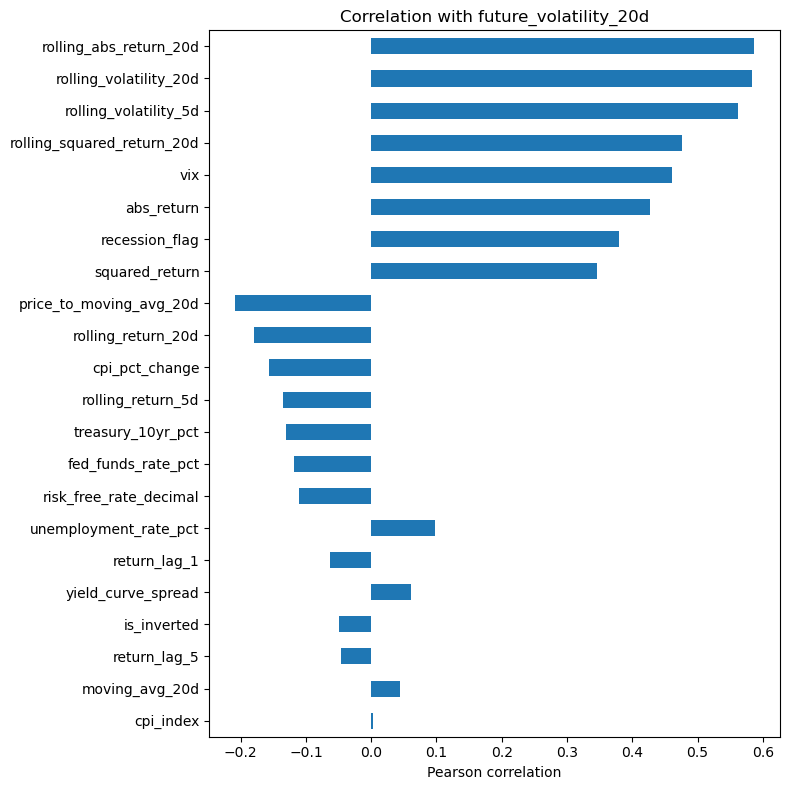

In [7]:
plt.figure(figsize=(8, 8))
target_corr.plot(kind="barh")
plt.title("Correlation with future_volatility_20d")
plt.xlabel("Pearson correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Feature-to-Feature Correlation (Redundancy Check)

Several candidate features are built from the same underlying signal at different windows (e.g. `abs_return` vs `rolling_abs_return_20d`, or `rolling_volatility_20d` vs `rolling_squared_return_20d`). If two features are almost perfectly correlated with each other, keeping both adds noise/collinearity without adding new information.

Any pair with `|correlation| > 0.9` is flagged below.

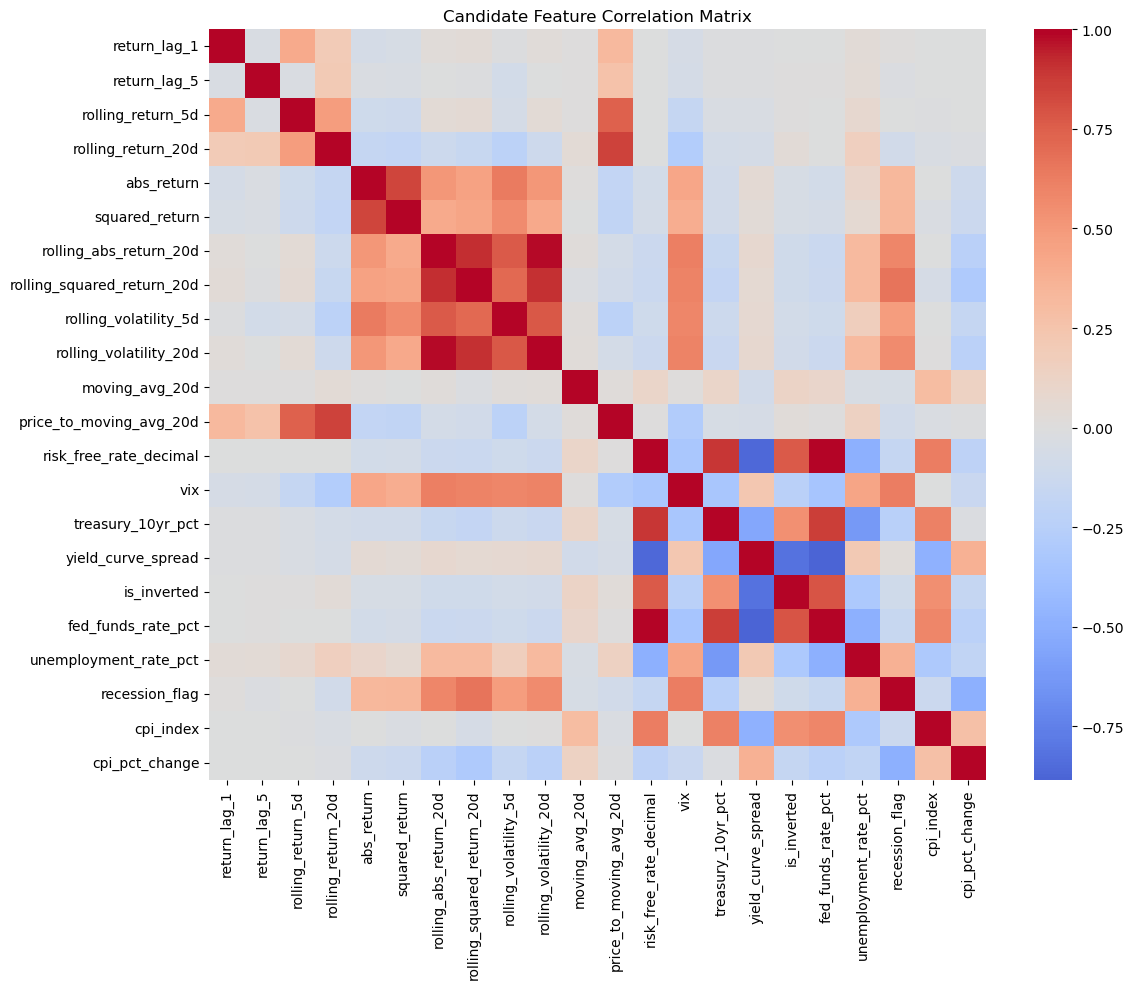

In [8]:
feature_corr = X_train.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(feature_corr, cmap="coolwarm", center=0, annot=False)
plt.title("Candidate Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [9]:
CORR_THRESHOLD = 0.9

corr_pairs = (
    feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

redundant_pairs = (
    corr_pairs[corr_pairs["correlation"].abs() > CORR_THRESHOLD]
    .sort_values("correlation", key=np.abs, ascending=False)
    .reset_index(drop=True)
)

redundant_pairs

,feature_1,feature_2,correlation
0,risk_free_rate_decimal,fed_funds_rate_pct,0.994255
1,rolling_abs_return_20d,rolling_volatility_20d,0.983931
2,rolling_abs_return_20d,rolling_squared_return_20d,0.915536
3,rolling_squared_return_20d,rolling_volatility_20d,0.911215


## Resolving Redundant Pairs

For each flagged pair, drop whichever feature has the weaker (absolute) correlation with the target, and keep the stronger one.

In [10]:
redundancy_dropped = set()

for _, pair in redundant_pairs.iterrows():
    f1, f2 = pair["feature_1"], pair["feature_2"]
    weaker = f1 if abs(target_corr[f1]) < abs(target_corr[f2]) else f2
    redundancy_dropped.add(weaker)

redundancy_dropped

{'risk_free_rate_decimal',
 'rolling_squared_return_20d',
 'rolling_volatility_20d'}

# Drop Raw Price/Index Level Features

`moving_avg_20d` and `cpi_index` are both raw levels rather than normalized signals. `moving_avg_20d` is on the same scale as `adjusted_close`, so it differs enormously by ticker (a few dollars for one stock, hundreds for another) and is not comparable across assets — `price_to_moving_avg_20d` already captures the useful trend signal in a scale-free way. Similarly, `cpi_index` just grows over time across the whole sample, while `cpi_pct_change` captures the actual month-to-month inflation signal. Both level columns are excluded regardless of their correlation score.

In [11]:
LEVEL_FEATURES_TO_DROP = {"moving_avg_20d", "cpi_index"}

LEVEL_FEATURES_TO_DROP

{'cpi_index', 'moving_avg_20d'}

# Random Forest Feature Importance

A quick Random Forest fit on the training data gives a non-linear, interaction-aware measure of how much each feature contributes to reducing prediction error. This is only used for ranking features here, not as the final model.

In [12]:
rf_selector = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_train, y_train)

rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=CANDIDATE_FEATURES
).sort_values(ascending=False)

rf_importance

rolling_abs_return_20d        0.432175
risk_free_rate_decimal        0.112110
cpi_pct_change                0.108039
vix                           0.062185
yield_curve_spread            0.038697
recession_flag                0.034002
rolling_volatility_5d         0.033841
moving_avg_20d                0.028117
fed_funds_rate_pct            0.023492
treasury_10yr_pct             0.021014
rolling_return_5d             0.018866
rolling_volatility_20d        0.018356
rolling_return_20d            0.014582
unemployment_rate_pct         0.013632
price_to_moving_avg_20d       0.013413
rolling_squared_return_20d    0.012274
cpi_index                     0.008298
return_lag_5                  0.001782
is_inverted                   0.001628
return_lag_1                  0.001570
abs_return                    0.000973
squared_return                0.000953
dtype: float64

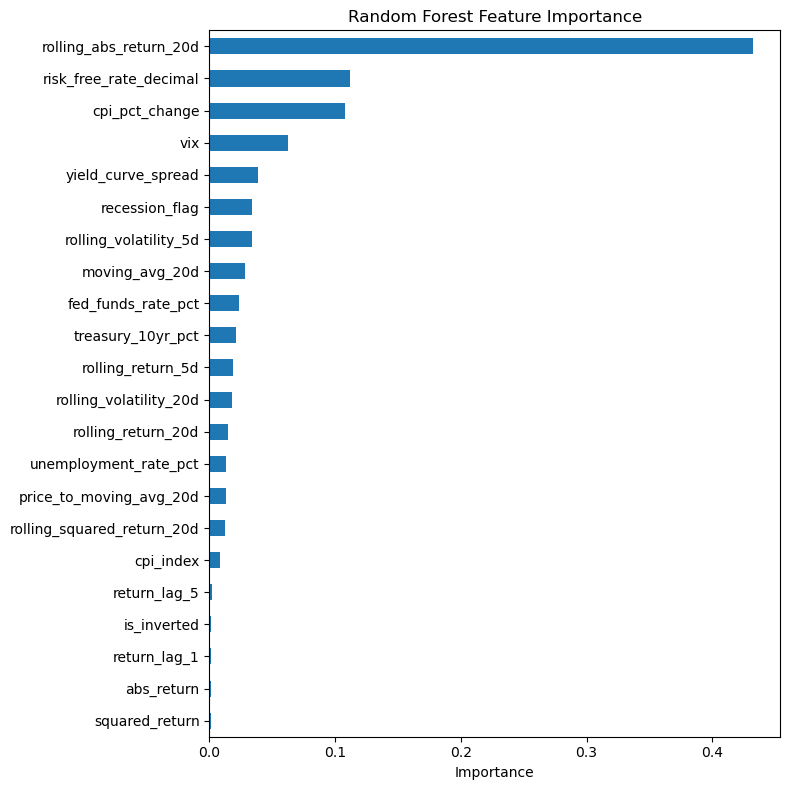

In [13]:
plt.figure(figsize=(8, 8))
rf_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Mutual Information

Mutual information measures how much knowing a feature reduces uncertainty about the target, without assuming a linear or tree-based relationship. It's a useful cross-check against the correlation and Random Forest rankings above.

In [14]:
mi_scores = mutual_info_regression(X_train, y_train, random_state=42)

mutual_info = pd.Series(mi_scores, index=CANDIDATE_FEATURES).sort_values(ascending=False)

mutual_info

moving_avg_20d                0.609066
rolling_volatility_20d        0.547937
rolling_squared_return_20d    0.546436
rolling_abs_return_20d        0.492515
cpi_pct_change                0.470129
cpi_index                     0.447948
fed_funds_rate_pct            0.355761
rolling_volatility_5d         0.320278
risk_free_rate_decimal        0.299446
unemployment_rate_pct         0.223825
yield_curve_spread            0.185345
treasury_10yr_pct             0.179827
price_to_moving_avg_20d       0.150427
rolling_return_20d            0.145543
vix                           0.140916
rolling_return_5d             0.135590
abs_return                    0.121707
squared_return                0.110845
return_lag_1                  0.107484
return_lag_5                  0.096576
recession_flag                0.040757
is_inverted                   0.019278
dtype: float64

# Combined Ranking Summary

Each method ranks features differently, so this combines all three into one table: absolute correlation with target, Random Forest importance, and mutual information, plus each feature's rank (1 = strongest) under each method and the average rank across all three.

In [15]:
summary = pd.DataFrame({
    "abs_target_corr": target_corr.abs(),
    "rf_importance": rf_importance,
    "mutual_info": mutual_info,
})

summary["corr_rank"] = summary["abs_target_corr"].rank(ascending=False)
summary["rf_rank"] = summary["rf_importance"].rank(ascending=False)
summary["mi_rank"] = summary["mutual_info"].rank(ascending=False)

summary["avg_rank"] = summary[["corr_rank", "rf_rank", "mi_rank"]].mean(axis=1)

summary["dropped_redundant"] = summary.index.isin(redundancy_dropped)
summary["dropped_level_feature"] = summary.index.isin(LEVEL_FEATURES_TO_DROP)

summary = summary.sort_values("avg_rank")

summary

,abs_target_corr,rf_importance,mutual_info,corr_rank,rf_rank,mi_rank,avg_rank,dropped_redundant,dropped_level_feature
rolling_abs_return_20d,0.586419,0.432175,0.492515,1.0,1.0,4.0,2.000000,False,False
rolling_volatility_20d,0.582745,0.018356,0.547937,2.0,12.0,2.0,5.333333,True,False
rolling_volatility_5d,0.561709,0.033841,0.320278,3.0,7.0,8.0,6.000000,False,False
cpi_pct_change,0.156179,0.108039,0.470129,11.0,3.0,5.0,6.333333,False,False
rolling_squared_return_20d,0.476521,0.012274,0.546436,4.0,16.0,3.0,7.666667,True,False
vix,0.460759,0.062185,0.140916,5.0,4.0,15.0,8.000000,False,False
risk_free_rate_decimal,0.110798,0.112110,0.299446,15.0,2.0,9.0,8.666667,True,False
fed_funds_rate_pct,0.118998,0.023492,0.355761,14.0,9.0,7.0,10.000000,False,False
moving_avg_20d,0.044207,0.028117,0.609066,21.0,8.0,1.0,10.000000,False,True
yield_curve_spread,0.060895,0.038697,0.185345,18.0,5.0,11.0,11.333333,False,False


# Final Selected Feature List

The final list keeps every candidate feature except:

- Features dropped for being the weaker half of a highly correlated (`|corr| > 0.9`) pair.
- The raw price/index level features (`moving_avg_20d`, `cpi_index`).

In [16]:
dropped_features = redundancy_dropped | LEVEL_FEATURES_TO_DROP

SELECTED_FEATURES = [f for f in CANDIDATE_FEATURES if f not in dropped_features]

print(f"Dropped ({len(dropped_features)}):", sorted(dropped_features))
print(f"Selected ({len(SELECTED_FEATURES)}):", SELECTED_FEATURES)

Dropped (5): ['cpi_index', 'moving_avg_20d', 'risk_free_rate_decimal', 'rolling_squared_return_20d', 'rolling_volatility_20d']
Selected (17): ['return_lag_1', 'return_lag_5', 'rolling_return_5d', 'rolling_return_20d', 'abs_return', 'squared_return', 'rolling_abs_return_20d', 'rolling_volatility_5d', 'price_to_moving_avg_20d', 'vix', 'treasury_10yr_pct', 'yield_curve_spread', 'is_inverted', 'fed_funds_rate_pct', 'unemployment_rate_pct', 'recession_flag', 'cpi_pct_change']


# Save Outputs

Two files are saved for the modeling notebooks to reuse:

- `selected_features.csv`: the final selected feature list, one feature per row.
- `feature_selection_summary.csv`: the full ranking table for every candidate feature, including which ones were dropped and why.

In [17]:
pd.DataFrame({"feature": SELECTED_FEATURES}).to_csv(
    FEATURE_DATA_PATH / "selected_features.csv",
    index=False
)

summary.reset_index(names="feature").to_csv(
    FEATURE_DATA_PATH / "feature_selection_summary.csv",
    index=False
)

print("Saved:", FEATURE_DATA_PATH / "selected_features.csv")
print("Saved:", FEATURE_DATA_PATH / "feature_selection_summary.csv")

Saved: ../../data/processed/features/selected_features.csv
Saved: ../../data/processed/features/feature_selection_summary.csv


# Conclusion

This notebook took the full candidate feature pool from feature engineering (22 numeric features) and narrowed it down to 17 using four checks: correlation with the target, feature-to-feature redundancy, Random Forest importance, and mutual information.

Four pairs came back above the 0.9 correlation threshold:

- `risk_free_rate_decimal` and `fed_funds_rate_pct` (0.99) — these two track the same short-term rate, so `risk_free_rate_decimal` was dropped and `fed_funds_rate_pct` kept.
- `rolling_abs_return_20d`, `rolling_volatility_20d`, and `rolling_squared_return_20d` are all pairwise correlated above 0.9 with each other — all three measure recent realized movement size over the same 20-day window. `rolling_abs_return_20d` had the strongest target correlation, Random Forest importance, and mutual information of the three, so it was kept and the other two were dropped.

`moving_avg_20d` and `cpi_index` were also dropped as raw level features that don't compare well across tickers or time, in favor of `price_to_moving_avg_20d` and `cpi_pct_change`.

Across all three ranking methods, `rolling_abs_return_20d` came out on top or near the top — which makes sense, since `future_volatility_20d` is itself a rolling standard deviation of returns, so recent realized movement size is naturally the strongest predictor of near-future volatility. `vix` and `cpi_pct_change` were the next-strongest non-return features. The remaining macro/FRED features ranked lower individually, but they still add regime context (rate levels, yield curve shape, recession flag) that the return-based features can't capture on their own, so they were kept rather than dropped.

The next modeling notebooks can load `selected_features.csv` instead of hardcoding the feature list, so this selection stays the single source of truth as more models are tried.